# 02 — Modeling: Baseline & Benchmarking

**Stage 3 objective:** establish a simple, interpretable benchmark (plain Logistic Regression, default settings, no resampling or class weighting) before introducing more complex models or handling class imbalance. This baseline is deliberately naive — it sets the floor that Stage 4's model/imbalance-handling comparison has to beat.

Evaluated on the **validation split** (last 6 weeks of `fraudTrain.csv`) defined in `src/preprocessing.py`. `fraudTest.csv` stays untouched.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score,
    roc_auc_score, confusion_matrix, precision_recall_curve, roc_curve
)

import preprocessing as pp

sns.set_style('whitegrid')
DATA_DIR = '../data'

## Load data and apply the Stage 2 split + preprocessing

In [2]:
train_raw = pp.engineer_features(pp.load_raw(f'{DATA_DIR}/fraudTrain.csv'))
test_raw = pp.engineer_features(pp.load_raw(f'{DATA_DIR}/fraudTest.csv'))

train_split, val_split = pp.temporal_train_val_split(train_raw, val_weeks=6)

X_train, y_train = pp.split_X_y(train_split)
X_val, y_val = pp.split_X_y(val_split)
X_test, y_test = pp.split_X_y(test_raw)

preprocessor = pp.build_preprocessor()
Xt_train = preprocessor.fit_transform(X_train)
Xt_val = preprocessor.transform(X_val)

print('Train:', Xt_train.shape, 'fraud:', y_train.sum(), f'({100 * y_train.mean():.3f}%)')
print('Val:  ', Xt_val.shape, 'fraud:', y_val.sum(), f'({100 * y_val.mean():.3f}%)')

Train: (1185094, 28) fraud: 6837 (0.577%)
Val:   (111581, 28) fraud: 669 (0.600%)


## Baseline: plain Logistic Regression (no class weighting, no resampling)

In [3]:
baseline_lr = LogisticRegression(max_iter=1000, random_state=42)
baseline_lr.fit(Xt_train, y_train)

val_proba = baseline_lr.predict_proba(Xt_val)[:, 1]
val_pred = (val_proba >= 0.5).astype(int)

## Evaluation metrics (validation set, default 0.5 threshold)

Deliberately **not** reporting accuracy as a headline metric — Stage 1 already showed a trivial always-legitimate classifier scores 99.4% accuracy while catching zero fraud.

In [4]:
def fraud_metrics(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)
    return {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_true, y_proba),
        'roc_auc': roc_auc_score(y_true, y_proba),
        'fpr': fpr,
        'confusion_matrix': cm,
    }

baseline_metrics = fraud_metrics(y_val, val_pred, val_proba)

print('Baseline Logistic Regression (threshold = 0.5)')
for k, v in baseline_metrics.items():
    if k != 'confusion_matrix':
        print(f'  {k:10s}: {v:.4f}')
print('\nConfusion matrix [[TN FP] [FN TP]]:')
print(baseline_metrics['confusion_matrix'])

Baseline Logistic Regression (threshold = 0.5)
  precision : 0.0702
  recall    : 0.0060
  f1        : 0.0110
  pr_auc    : 0.2632
  roc_auc   : 0.8265
  fpr       : 0.0005

Confusion matrix [[TN FP] [FN TP]]:
[[110859     53]
 [   665      4]]


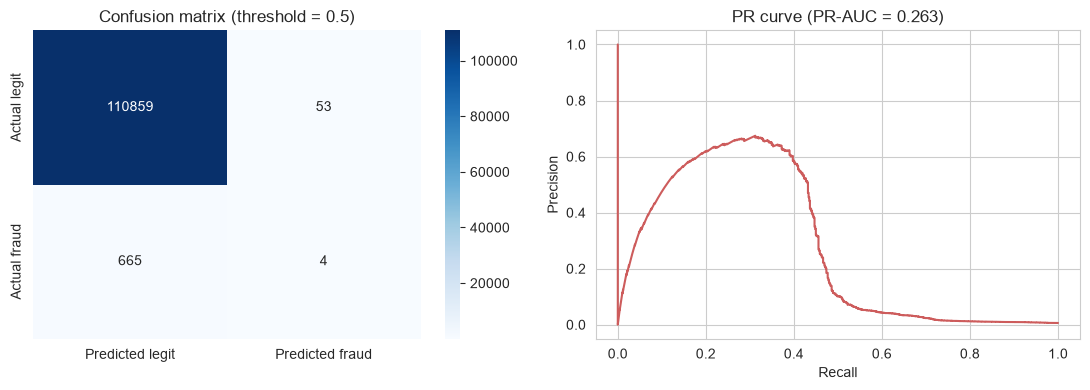

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(baseline_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted legit', 'Predicted fraud'],
            yticklabels=['Actual legit', 'Actual fraud'], ax=axes[0])
axes[0].set_title('Confusion matrix (threshold = 0.5)')

prec, rec, _ = precision_recall_curve(y_val, val_proba)
axes[1].plot(rec, prec, color='indianred')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f"PR curve (PR-AUC = {baseline_metrics['pr_auc']:.3f})")

plt.tight_layout()
plt.show()

## Baseline takeaway

This result is the floor, not the ceiling. At the default 0.5 threshold with no imbalance handling, plain Logistic Regression's recall reflects how conservative an untouched-imbalance model is about predicting the rare class — most probabilities never cross 0.5. PR-AUC and ROC-AUC (threshold-independent) are the numbers that matter most for comparing this baseline against the class-weighted / resampled / tree-based models in Stage 4, since the operating threshold itself is not decided until Stage 5.